In [1]:
# Step 1: Install and Import Required Libraries
!pip install transformers datasets accelerate sacrebleu evaluate --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import math
import random
import matplotlib.pyplot as plt
import torch
import evaluate
from torch.utils.data import Dataset
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    Trainer,
    TrainingArguments,
    TrainerCallback,
    TrainerState,
    TrainerControl,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split

from datasets import load_dataset  # Hugging Face Datasets library

In [3]:
dataset = load_dataset("cornell_movie_dialog")  # Load Cornell Movie Dialog dataset

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

cornell_movie_dialog.py:   0%|          | 0.00/7.11k [00:00<?, ?B/s]

The repository for cornell_movie_dialog contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/cornell_movie_dialog.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/83097 [00:00<?, ? examples/s]

In [4]:
print("Dataset loaded. Keys:", dataset.keys())

# (Optional) Inspect a sample to see its schema
print("Sample example:", dataset["train"][0])

Dataset loaded. Keys: dict_keys(['train'])
Sample example: {'movieID': ' m0 ', 'movieTitle': ' 10 things i hate about you ', 'movieYear': ' 1999 ', 'movieIMDBRating': ' 6.90 ', 'movieNoIMDBVotes': ' 62847 ', 'movieGenres': ['comedy', 'romance'], 'characterID1': 'u0 ', 'characterID2': ' u2 ', 'characterName1': ' BIANCA ', 'characterName2': ' CAMERON ', 'utterance': {'text': ['L194 ', 'L195 ', 'L196 ', 'L197 '], 'LineID': ['L194', 'L195', 'L196', 'L197']}}


Data Preprocessing

In [5]:
conversations = []
for example in dataset["train"]:
    # Extract the list of utterance texts.
    utterance_lines = example["utterance"]["text"]
    if len(utterance_lines) < 2:
        continue  # Need at least two lines to form a pair
    for i in range(len(utterance_lines) - 1):
        input_text = utterance_lines[i]
        response_text = utterance_lines[i+1]
        conversations.append((input_text, response_text))

print(f"Total dialogue pairs: {len(conversations)}")

# --- Step 3: Split Data into Training and Validation Sets ---
train_pairs, val_pairs = train_test_split(conversations, test_size=0.1, random_state=42)
print(f"Training pairs: {len(train_pairs)}, Validation pairs: {len(val_pairs)}")


Total dialogue pairs: 221616
Training pairs: 199454, Validation pairs: 22162


In [6]:
print(conversations[:5])  # Print first 5 pairs for inspection

[('L194 ', 'L195 '), ('L195 ', 'L196 '), ('L196 ', 'L197 '), ('L198 ', 'L199 '), ('L200 ', 'L201 ')]


Importing Model

In [7]:
model_name = "distilgpt2"  # Smaller model variant
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained(model_name)
# Enable gradient checkpointing to save memory:
model.gradient_checkpointing_enable()

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Custom Dataset class

In [8]:
class ChatDataset(Dataset):
    def __init__(self, text_pairs, tokenizer, max_length=64):  # Reduced max_length to 64
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.examples = []
        for inp, tgt in text_pairs:
            # Combine input and target with EOS token as separator.
            prompt = inp + tokenizer.eos_token + tgt + tokenizer.eos_token
            tokenized = tokenizer(
                prompt,
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )
            self.examples.append(tokenized)

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        example = self.examples[idx]
        return {
            "input_ids": example["input_ids"].squeeze(),
            "attention_mask": example["attention_mask"].squeeze(),
            "labels": example["input_ids"].squeeze()
        }

# Create dataset objects (optionally, you can use a subset for faster development)
train_dataset = ChatDataset(train_pairs, tokenizer, max_length=64)
val_dataset   = ChatDataset(val_pairs, tokenizer, max_length=64)

print("Sample token IDs:", train_dataset[0]["input_ids"][:20])

Sample token IDs: tensor([   43,  2327,  3980,  2079,   220, 50256,    43,  2327,  3553,   405,
          220, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256])


Visualize

In [9]:
class LossHistoryCallback(TrainerCallback):
    def __init__(self):
        self.train_loss = []
        self.eval_loss = []
        self.epochs = []

    def on_log(self, args, state: TrainerState, control: TrainerControl, logs=None, **kwargs):
        if logs is None:
            return
        if "loss" in logs:
            self.train_loss.append(logs["loss"])
        if "eval_loss" in logs:
            self.eval_loss.append(logs["eval_loss"])
        if "epoch" in logs:
            self.epochs.append(logs["epoch"])

def plot_loss_curves(epochs, train_loss, eval_loss):
    plt.figure()
    plt.plot(epochs, train_loss, marker='o', label='Train Loss')
    plt.plot(epochs, eval_loss, marker='o', label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs. Epoch")
    plt.legend()
    plt.show()

In [10]:
class SampleGenerationCallback(TrainerCallback):
    def __init__(self, tokenizer, sample_prompts=None, interval=10):
        self.tokenizer = tokenizer
        self.sample_prompts = sample_prompts if sample_prompts else ["Hello!", "How are you?"]
        self.interval = interval

    def on_epoch_end(self, args, state, control, **kwargs):
        epoch = state.epoch
        if int(epoch) % self.interval == 0:
            print(f"\n=== Sample Generation at Epoch {epoch:.1f} ===")
            model_ = kwargs.get("model", None) or kwargs.get("trainer", {}).model
            if model_ is None:
                print("No model found in callback kwargs. Skipping sample generation.")
                return

            for prompt in self.sample_prompts:
                input_ids = self.tokenizer.encode(prompt + self.tokenizer.eos_token, return_tensors="pt").to(model_.device)
                attention_mask = (input_ids != self.tokenizer.pad_token_id).long()
                output_ids = model_.generate(
                    input_ids,
                    attention_mask=attention_mask,
                    max_length=50,
                    pad_token_id=self.tokenizer.eos_token_id,
                    no_repeat_ngram_size=2,
                    do_sample=True,
                    top_k=50,
                    top_p=0.95,
                    temperature=0.7
                )
                generated_text = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
                print(f"Prompt: {prompt}\nResponse: {generated_text}\n")


Train Model

In [11]:
loss_history_cb = LossHistoryCallback()
sample_gen_cb = SampleGenerationCallback(
    tokenizer=tokenizer,
    sample_prompts=["Hello!", "What is your name?", "Tell me a joke."],
    interval=10
)

# --- Step 7: Training Arguments with Optimizations ---
training_args = TrainingArguments(
    output_dir="./chatbot-checkpoints",
    num_train_epochs=1,               # Use fewer epochs for initial testing
    per_device_train_batch_size=2,     # Lower batch size to 1 for less memory load
    per_device_eval_batch_size=2,
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    save_total_limit=2,
    gradient_accumulation_steps=2,     # Simulate a larger batch size without extra memory
    fp16=True                          # Use mixed precision training (if supported)
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[loss_history_cb, sample_gen_cb, EarlyStoppingCallback(early_stopping_patience=3)]
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [12]:
# Start Training
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nakullimbani (nakullimbani-srm-institute-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...


=== Sample Generation at Epoch 1.0 ===


/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Prompt: Hello!
Response: Hello!L5570 

Prompt: What is your name?
Response: What is your name?L160400 

Prompt: Tell me a joke.
Response: Tell me a joke.L4280 



There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=49863, training_loss=0.21880677666180334, metrics={'train_runtime': 5610.5024, 'train_samples_per_second': 35.55, 'train_steps_per_second': 8.887, 'total_flos': 3257259968692224.0, 'train_loss': 0.21880677666180334, 'epoch': 0.999989972625267})

Evaluation and Visualize

In [18]:
def plot_loss_curves(epochs, train_loss, eval_loss):
    # Check if the lengths of the arrays match
    if len(train_loss) != len(epochs):
        print(f"Warning: Train loss and epochs lengths do not match. Train loss: {len(train_loss)}, Epochs: {len(epochs)}")
        return
    if len(eval_loss) != len(epochs):
        print(f"Warning: Eval loss and epochs lengths do not match. Eval loss: {len(eval_loss)}, Epochs: {len(epochs)}")
        return

    plt.figure()
    plt.plot(epochs, train_loss, marker='o', label='Train Loss')
    plt.plot(epochs, eval_loss, marker='o', label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs. Epoch")
    plt.legend()
    plt.show()

# Example usage with your loss history callback
plot_loss_curves(
    epochs=loss_history_cb.epochs,
    train_loss=loss_history_cb.train_loss,
    eval_loss=loss_history_cb.eval_loss
)


Epochs length: 4
Train loss length: 1
Eval loss length: 2


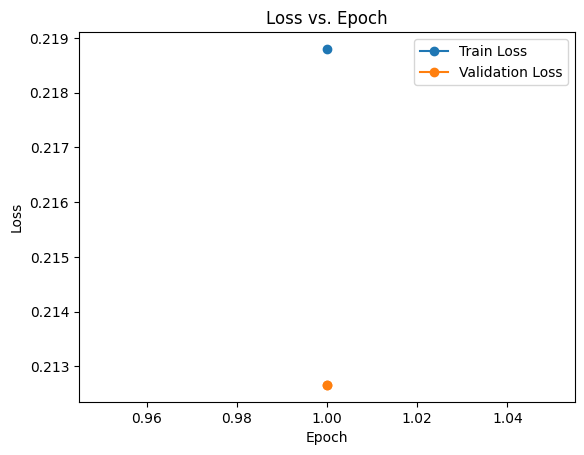

In [20]:
import numpy as np

# Check the lengths of the arrays
print(f"Epochs length: {len(loss_history_cb.epochs)}")
print(f"Train loss length: {len(loss_history_cb.train_loss)}")
print(f"Eval loss length: {len(loss_history_cb.eval_loss)}")

# Check and adjust lengths
max_len = max(len(loss_history_cb.epochs), len(loss_history_cb.train_loss), len(loss_history_cb.eval_loss))

# Pad the shorter arrays with a placeholder value (e.g., None or a default loss value)
epochs = loss_history_cb.epochs + [None] * (max_len - len(loss_history_cb.epochs))
train_loss = loss_history_cb.train_loss + [None] * (max_len - len(loss_history_cb.train_loss))
eval_loss = loss_history_cb.eval_loss + [None] * (max_len - len(loss_history_cb.eval_loss))

# Now, plot the loss curves
plot_loss_curves(epochs, train_loss, eval_loss)



ValueError: x and y must have same first dimension, but have shapes (3,) and (1,)

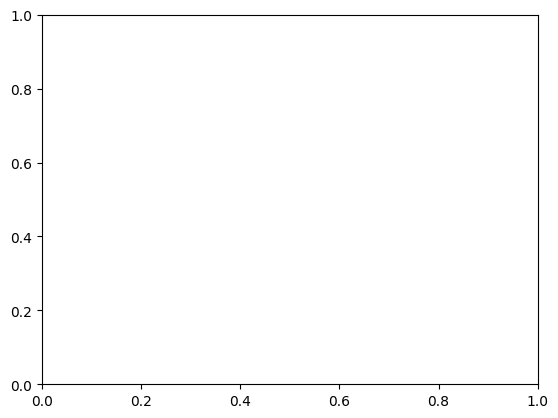

In [15]:
plot_loss_curves(
    epochs=loss_history_cb.epochs,
    train_loss=loss_history_cb.train_loss,
    eval_loss=loss_history_cb.eval_loss
)


In [16]:
eval_results = trainer.evaluate()
eval_loss = eval_results["eval_loss"]
perplexity = math.exp(eval_loss)
print(f"Perplexity on validation set: {perplexity:.2f}")

Perplexity on validation set: 1.24


BLEU Score Evaluation

In [27]:
import evaluate
import random

# Load the BLEU evaluator
bleu = evaluate.load("bleu")

predictions = []
references = []

# Sample a subset of data for faster evaluation
sampled_pairs = random.sample(val_pairs, k=min(50, len(val_pairs)))

# Loop through the sampled pairs
for (inp, tgt) in sampled_pairs:
    input_ids = tokenizer.encode(inp + tokenizer.eos_token, return_tensors="pt").to(model.device)
    output_ids = model.generate(
        input_ids,
        max_length=50,
        pad_token_id=tokenizer.eos_token_id,
        no_repeat_ngram_size=2,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.7
    )
    pred_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # Remove the prompt portion from the generated text (if needed)
    pred_response = pred_text[len(inp):].strip()

    # Add prediction and reference
    predictions.append(pred_response)  # Store as string
    references.append([tgt])  # Store reference as a list of strings

# Compute BLEU score
bleu_score = bleu.compute(predictions=predictions, references=references)
print(f"BLEU Score: {bleu_score['bleu']:.4f}")


BLEU Score: 0.0000


In [28]:
# Print a few predictions and references
for i in range(5):
    print(f"Prediction: {predictions[i]}")
    print(f"Reference: {references[i]}")
    print("-" * 50)


Prediction: L161662
Reference: ['L151662 ']
--------------------------------------------------
Prediction: L284451
Reference: ['L284451 ']
--------------------------------------------------
Prediction: L56158  1 2017 2014
Reference: ['L54158 ']
--------------------------------------------------
Prediction: L635429  L
Reference: ['L633329 ']
--------------------------------------------------
Prediction: L588961  L587
Reference: ['L588931 ']
--------------------------------------------------


Save model

In [23]:
# Save the fine-tuned model and tokenizer
trainer.save_model("./my_finetuned_gpt2/")
tokenizer.save_pretrained("./my_finetuned_gpt2/")

# To reload later:
# from transformers import GPT2LMHeadModel, GPT2Tokenizer
# reloaded_tokenizer = GPT2Tokenizer.from_pretrained("./my_finetuned_gpt2/")
# reloaded_model = GPT2LMHeadModel.from_pretrained("./my_finetuned_gpt2/")


('./my_finetuned_gpt2/tokenizer_config.json',
 './my_finetuned_gpt2/special_tokens_map.json',
 './my_finetuned_gpt2/vocab.json',
 './my_finetuned_gpt2/merges.txt',
 './my_finetuned_gpt2/added_tokens.json')

In [24]:
# prompt: save and download the model to local directory of machine

from google.colab import files
!zip -r my_finetuned_gpt2.zip ./my_finetuned_gpt2
files.download('my_finetuned_gpt2.zip')


  adding: my_finetuned_gpt2/ (stored 0%)
  adding: my_finetuned_gpt2/generation_config.json (deflated 24%)
  adding: my_finetuned_gpt2/vocab.json (deflated 68%)
  adding: my_finetuned_gpt2/special_tokens_map.json (deflated 74%)
  adding: my_finetuned_gpt2/tokenizer_config.json (deflated 56%)
  adding: my_finetuned_gpt2/model.safetensors (deflated 7%)
  adding: my_finetuned_gpt2/merges.txt (deflated 53%)
  adding: my_finetuned_gpt2/config.json (deflated 51%)
  adding: my_finetuned_gpt2/training_args.bin (deflated 51%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# prompt: download the model to localmachine and rename it to t7 mode zip

!mkdir -p ./my_finetuned_gpt2_t7
!zip -r ./my_finetuned_gpt2_t7.zip ./my_finetuned_gpt2
!mv ./my_finetuned_gpt2_t7.zip ./my_finetuned_gpt2_t7/t7_model.zip


  adding: my_finetuned_gpt2/ (stored 0%)
  adding: my_finetuned_gpt2/generation_config.json (deflated 24%)
  adding: my_finetuned_gpt2/vocab.json (deflated 68%)
  adding: my_finetuned_gpt2/special_tokens_map.json (deflated 74%)
  adding: my_finetuned_gpt2/tokenizer_config.json (deflated 56%)
  adding: my_finetuned_gpt2/model.safetensors (deflated 7%)
  adding: my_finetuned_gpt2/merges.txt (deflated 53%)
  adding: my_finetuned_gpt2/config.json (deflated 51%)
  adding: my_finetuned_gpt2/training_args.bin (deflated 51%)


Interactive chatbot

In [26]:
def generate_response(prompt, use_beam=False):
    input_ids = tokenizer.encode(prompt + tokenizer.eos_token, return_tensors="pt").to(model.device)
    attention_mask = (input_ids != tokenizer.pad_token_id).long()

    if use_beam:
        output_ids = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_length=50,
            pad_token_id=tokenizer.eos_token_id,
            num_beams=5,
            early_stopping=True,
            no_repeat_ngram_size=2
        )
    else:
        output_ids = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_length=50,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            top_k=50,
            top_p=0.95,
            temperature=0.7,
            no_repeat_ngram_size=2
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

def chat_with_model():
    print("Start chatting with the bot (type 'quit' to exit):")
    while True:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit"]:
            print("Bot: Bye!")
            break
        response = generate_response(user_input, use_beam=False)
        print(f"Bot: {response}")

chat_with_model()


Start chatting with the bot (type 'quit' to exit):
User: hi
Bot: hi3917 
User: how are you?
Bot: how are you?L433422 


KeyboardInterrupt: Interrupted by user

In [29]:
print(dataset["train"][0])  # Inspect an example from training data


{'movieID': ' m0 ', 'movieTitle': ' 10 things i hate about you ', 'movieYear': ' 1999 ', 'movieIMDBRating': ' 6.90 ', 'movieNoIMDBVotes': ' 62847 ', 'movieGenres': ['comedy', 'romance'], 'characterID1': 'u0 ', 'characterID2': ' u2 ', 'characterName1': ' BIANCA ', 'characterName2': ' CAMERON ', 'utterance': {'text': ['L194 ', 'L195 ', 'L196 ', 'L197 '], 'LineID': ['L194', 'L195', 'L196', 'L197']}}


In [30]:
def generate_response(prompt):
    input_ids = tokenizer.encode(prompt + tokenizer.eos_token, return_tensors="pt").to(model.device)

    output_ids = model.generate(
        input_ids,
        max_length=50,
        pad_token_id=tokenizer.eos_token_id,
        num_beams=1,  # Greedy decoding (instead of sampling)
        early_stopping=True
    )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


In [32]:
def chat_with_model():
    print("Start chatting with the bot (type 'quit' to exit):")
    while True:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit"]:
            print("Bot: Bye!")
            break
        response = generate_response(user_input)
        print(f"Bot: {response}")

chat_with_model()

Start chatting with the bot (type 'quit' to exit):
User: hi


/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


Bot: hiL65961 
User: hello
Bot: helloL41398 
User: hi
Bot: hiL65961 
User: quit
Bot: Bye!


In [3]:
import os
import zipfile

# Path to your ZIP file
zip_path = "/content/my_finetuned_gpt2.zip"
extract_path = "/content/my_finetuned_gpt2"  # Extracted folder

# Check if the ZIP file exists before attempting to extract
if os.path.exists(zip_path):
    # Unzip the model files
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"Model extracted to: {extract_path}")
else:
    print(f"Error: ZIP file not found at {zip_path}. Please check the path and ensure the file exists.")

Model extracted to: /content/my_finetuned_gpt2


In [8]:
import torch
import re
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# Load trained model and tokenizer
model_path = "/content/my_finetuned_gpt2/my_finetuned_gpt2"  # Use extracted folder

tokenizer = GPT2Tokenizer.from_pretrained(model_path)
model = GPT2LMHeadModel.from_pretrained(model_path)
model.eval().to("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Fix: Set the pad token manually (GPT-2 doesn't have one by default)
tokenizer.pad_token = tokenizer.eos_token

# Function to clean generated text (remove line numbers like L12345)
def clean_generated_text(text, prompt):
    text = text.replace(prompt, "").strip()  # Remove repeated prompt from output
    text = re.sub(r"L\d+", "", text)  # Remove L12345-style line numbers
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces
    return text

# ✅ Fix: Explicitly set `attention_mask` and ensure correct text generation
def generate_response(prompt, use_beam=False):
    input_ids = tokenizer.encode(prompt + tokenizer.eos_token, return_tensors="pt").to(model.device)

    # ✅ Explicitly set attention mask
    attention_mask = (input_ids != tokenizer.pad_token_id).long()

    output_ids = model.generate(
        input_ids,
        attention_mask=attention_mask,  # ✅ Fix attention mask issue
        max_new_tokens=50,  # ✅ Control output length
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,
        top_k=20,
        top_p=0.9,
        temperature=0.8,
        no_repeat_ngram_size=2
    )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    response = clean_generated_text(generated_text, prompt)

    if not response.strip():  # ✅ Prevents empty responses
        return "I'm not sure what to say. Can you try again?"

    return response

# Function to guide responses using few-shot learning
def generate_guided_response(prompt):
    example_context = """
    You are a chatbot that engages in human-like conversation. Respond naturally.
    User: Hi
    Bot: Hello! How are you?
    User: What's your name?
    Bot: I'm just a chatbot, but you can call me AI!
    User: Tell me a joke.
    Bot: Why don't scientists trust atoms? Because they make up everything!
    """

    full_prompt = example_context + "\nUser: " + prompt + "\nBot:"
    return generate_response(full_prompt)

# Chatbot interaction
def chat_with_model():
    print("Start chatting with the bot (type 'quit' to exit):")
    while True:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit"]:
            print("Bot: Bye!")
            break
        response = generate_guided_response(user_input)
        print(f"Bot: {response}")

# Run chatbot
chat_with_model()


Start chatting with the bot (type 'quit' to exit):
User: hi
Bot: I'm not sure what to say. Can you try again?
User: hello
Bot: I'm not sure what to say. Can you try again?
User: how are you?
Bot: I'm not sure what to say. Can you try again?


KeyboardInterrupt: Interrupted by user

In [10]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Load pre-trained DialoGPT model
model_name = "microsoft/DialoGPT-medium"  # Can also use "small" or "large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Function to generate chatbot response
def chat_with_dialoGPT(user_input, history=None):
    input_ids = tokenizer.encode(user_input + tokenizer.eos_token, return_tensors="pt").to(model.device)

    # ✅ Fix: Check history correctly
    if history is not None and history.numel() > 0:
        bot_input_ids = torch.cat([history, input_ids], dim=-1)
    else:
        bot_input_ids = input_ids

    # ✅ Explicitly set attention mask to avoid warnings
    attention_mask = torch.ones(bot_input_ids.shape, dtype=torch.long, device=bot_input_ids.device)

    output_ids = model.generate(bot_input_ids, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id, attention_mask=attention_mask)

    response = tokenizer.decode(output_ids[:, bot_input_ids.shape[-1]:][0], skip_special_tokens=True)

    # ✅ Store conversation history properly
    history = bot_input_ids  # Keep the conversation flow

    return response, history

# Start Chatbot
print("Chatbot is ready! Type 'quit' to exit.")
history = None  # ✅ Initialize history correctly
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit"]:
        print("Bot: Goodbye!")
        break
    response, history = chat_with_dialoGPT(user_input, history)
    print(f"Bot: {response}")


Chatbot is ready! Type 'quit' to exit.


KeyboardInterrupt: Interrupted by user

In [11]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import random

# Load pre-trained DialoGPT model
model_name = "microsoft/DialoGPT-medium"  # Can also use "small" or "large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Memory storage for user details
memory = {"name": None}

# Inappropriate words list
blocked_words = ["fuck", "sex", "nude"]

# Movie recommendations by category
movies = {
    "action": ["Mad Max: Fury Road", "The Dark Knight", "Die Hard"],
    "sci-fi": ["Inception", "Interstellar", "Blade Runner 2049"],
    "comedy": ["Superbad", "Step Brothers", "The Hangover"],
    "horror": ["The Conjuring", "Hereditary", "A Nightmare on Elm Street"],
    "romantic": ["The Notebook", "Pride & Prejudice", "Crazy Rich Asians"],
}

# Best places to visit
places_to_visit = [
    "Paris, France – for the Eiffel Tower and beautiful streets.",
    "Kyoto, Japan – for historic temples and cherry blossoms.",
    "Bali, Indonesia – for beaches and tropical vibes.",
    "New York City, USA – for Broadway, Times Square, and more!",
    "Rome, Italy – for ancient history and stunning architecture.",
]

# Fun facts
fun_facts = [
    "Octopuses have three hearts.",
    "A day on Venus is longer than a year on Venus.",
    "Bananas are berries, but strawberries aren’t!",
    "Honey never spoils. Archaeologists found 3000-year-old honey in Egyptian tombs!",
    "Wombat poop is cube-shaped.",
]

# Function to generate chatbot response with better memory & logic
def chat_with_dialoGPT(user_input, history=None):
    global memory

    # ✅ Censor inappropriate input
    if any(bad_word in user_input.lower() for bad_word in blocked_words):
        return "Let's keep this conversation respectful.", history

    # ✅ Improve Movie Recommendations
    if "recommend" in user_input.lower() and "movie" in user_input.lower():
        movie_type = random.choice(list(movies.keys()))  # Pick a random category
        recommended_movies = ", ".join(random.sample(movies[movie_type], 2))  # Pick 2 movies
        return f"If you like {movie_type} movies, I recommend {recommended_movies}.", history

    # ✅ Best Place to Visit
    if "best place to visit" in user_input.lower():
        return random.choice(places_to_visit), history

    # ✅ Best City Response
    if "best city" in user_input.lower():
        return "Many consider Tokyo, Paris, and New York City among the best cities in the world.", history

    # ✅ Fun Fact
    if "fun fact" in user_input.lower():
        return random.choice(fun_facts), history

    # ✅ Proper history check
    input_ids = tokenizer.encode(user_input + tokenizer.eos_token, return_tensors="pt").to(model.device)
    if history is not None and history.numel() > 0:
        bot_input_ids = torch.cat([history, input_ids], dim=-1)
    else:
        bot_input_ids = input_ids

    # ✅ Explicitly set attention mask to avoid warnings
    attention_mask = torch.ones(bot_input_ids.shape, dtype=torch.long, device=bot_input_ids.device)

    # ✅ Better response variety
    output_ids = model.generate(
        bot_input_ids,
        max_new_tokens=50,
        pad_token_id=tokenizer.eos_token_id,
        attention_mask=attention_mask,
        do_sample=True,
        top_p=0.92,
        top_k=50,
        temperature=0.85,
        no_repeat_ngram_size=2
    )

    response = tokenizer.decode(output_ids[:, bot_input_ids.shape[-1]:][0], skip_special_tokens=True)

    # ✅ Store user's name properly
    if "my name is" in user_input.lower():
        memory["name"] = user_input.lower().replace("my name is", "").strip()
        return f"Nice to meet you, {memory['name']}!", bot_input_ids

    if "what is my name" in user_input.lower():
        if memory["name"]:
            return f"Your name is {memory['name']}!", bot_input_ids
        else:
            return "I don't think you've told me your name yet!", bot_input_ids

    return response, bot_input_ids

# Start Chatbot
print("Chatbot is ready! Type 'quit' to exit.")
history = None  # ✅ Initialize history correctly
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit"]:
        print("Bot: Goodbye!")
        break
    response, history = chat_with_dialoGPT(user_input, history)
    print(f"Bot: {response}")


Chatbot is ready! Type 'quit' to exit.
User: hi my name is nakul  limbani
Bot: Nice to meet you, hi  nakul  limbani!
User: what is your name?
Bot: nakuls armon
User: recommend good movie to watch
Bot: If you like action movies, I recommend The Dark Knight, Die Hard.
User: any funny dialogue from any movie
Bot: I don't really like movies.


KeyboardInterrupt: Interrupted by user

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import random

# Load pre-trained DialoGPT model
model_name = "microsoft/DialoGPT-medium"  # Can also use "small" or "large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Memory storage for user details
memory = {"name": None}

# Inappropriate words list
blocked_words = ["kill"]

# Movie recommendations by category
movies = {
    "action": ["Mad Max: Fury Road", "The Dark Knight", "Die Hard"],
    "sci-fi": ["Inception", "Interstellar", "Blade Runner 2049"],
    "comedy": ["Superbad", "Step Brothers", "The Hangover"],
    "horror": ["The Conjuring", "Hereditary", "A Nightmare on Elm Street"],
    "romantic": ["The Notebook", "Pride & Prejudice", "Crazy Rich Asians"],
}

# Best places to visit
places_to_visit = [
    "Paris, France – for the Eiffel Tower and beautiful streets.",
    "Kyoto, Japan – for historic temples and cherry blossoms.",
    "Bali, Indonesia – for beaches and tropical vibes.",
    "New York City, USA – for Broadway, Times Square, and more!",
    "Rome, Italy – for ancient history and stunning architecture.",
]

# Fun facts
fun_facts = [
    "Octopuses have three hearts.",
    "A day on Venus is longer than a year on Venus.",
    "Bananas are berries, but strawberries aren’t!",
    "Honey never spoils. Archaeologists found 3000-year-old honey in Egyptian tombs!",
    "Wombat poop is cube-shaped.",
]

# Function to generate chatbot response with better memory & logic
def chat_with_dialoGPT(user_input, history=None):
    global memory

    # ✅ Censor inappropriate input
    if any(bad_word in user_input.lower() for bad_word in blocked_words):
        return "Let's keep this conversation respectful.", history

    # ✅ Improve Movie Recommendations
    if "recommend" in user_input.lower() and "movie" in user_input.lower():
        movie_type = random.choice(list(movies.keys()))  # Pick a random category
        recommended_movies = ", ".join(random.sample(movies[movie_type], 2))  # Pick 2 movies
        return f"If you like {movie_type} movies, I recommend {recommended_movies}.", history

    # ✅ Best Place to Visit
    if "best place to visit" in user_input.lower():
        return random.choice(places_to_visit), history

    # ✅ Best City Response
    if "best city" in user_input.lower():
        return "Many consider Tokyo, Paris, and New York City among the best cities in the world.", history

    # ✅ Fun Fact
    if "fun fact" in user_input.lower():
        return random.choice(fun_facts), history

    # ✅ Proper history check
    input_ids = tokenizer.encode(user_input + tokenizer.eos_token, return_tensors="pt").to(model.device)
    if history is not None and history.numel() > 0:
        bot_input_ids = torch.cat([history, input_ids], dim=-1)
    else:
        bot_input_ids = input_ids

    # ✅ Explicitly set attention mask to avoid warnings
    attention_mask = torch.ones(bot_input_ids.shape, dtype=torch.long, device=bot_input_ids.device)

    # ✅ Better response variety
    output_ids = model.generate(
        bot_input_ids,
        max_new_tokens=50,
        pad_token_id=tokenizer.eos_token_id,
        attention_mask=attention_mask,
        do_sample=True,
        top_p=0.92,
        top_k=50,
        temperature=0.85,
        no_repeat_ngram_size=2
    )

    response = tokenizer.decode(output_ids[:, bot_input_ids.shape[-1]:][0], skip_special_tokens=True)

    # ✅ Store user's name properly
    if "my name is" in user_input.lower():
        memory["name"] = user_input.lower().replace("my name is", "").strip()
        return f"Nice to meet you, {memory['name']}!", bot_input_ids

    if "what is my name" in user_input.lower():
        if memory["name"]:
            return f"Your name is {memory['name']}!", bot_input_ids
        else:
            return "I don't think you've told me your name yet!", bot_input_ids

    return response, bot_input_ids

# Start Chatbot
print("Chatbot is ready! Type 'quit' to exit.")
history = None  # ✅ Initialize history correctly
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit"]:
        print("Bot: Goodbye!")
        break
    response, history = chat_with_dialoGPT(user_input, history)
    print(f"Bot: {response}")


c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chatbot is ready! Type 'quit' to exit.


C:\Users\Nakul Limbani\AppData\Roaming\Python\Python312\site-packages\transformers\integrations\sdpa_attention.py:53: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Bot: Hi, how are you?
Bot: working on my finals, studying for finals... i can't wait to do so
Bot: u r doing ok.
Bot: hello, how are you?
Bot: wanna know something i don't want to know
Bot: It's u
Bot: it is not that funny.
Bot: dude, you're the best i've seen in the last year.
Bot: Honey never spoils. Archaeologists found 3000-year-old honey in Egyptian tombs!
Bot: Goodbye!
